Import libraries and load dataset


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

#Loading the dataset
data_path = "cardio_train.csv"

df = pd.read_csv(data_path, sep=';')

print("shape before anything:")
print(df.shape)

# Dataset information

print("columns:", df.columns.tolist())
print("\ninfo:")
print(df.info())
print("\nfirst few rows:")
print(df.head())
print("\nsummary stats (numeric):")
print(df.describe())
print("\nmissing values per column:")
print(df.isna().sum())




shape before anything:
(70000, 13)
columns: ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None

first few rows:
   id    age  g

Data cleaning


In [104]:
data = df.copy() #copy of the dataset to perserve the original

# getting rid of duplicates if any
before_dups = data.shape[0]
data = data.drop_duplicates()
after_dups = data.shape[0]
print(f"duplicates removed: {before_dups - after_dups}")

# Converting age to age_years, which was given in days
data["age_years"] = (data["age"] / 365).round(1)

# Dropping age, since we converted and made an attribute age_years
data = data.drop(columns=["age"])


print("\nPreview after cleaning:")
data.head()


duplicates removed: 0

Preview after cleaning:


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.4
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.4
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.7
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.3
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.9


Descriptive statistics of the dataset


summary stats with age_years:
          age_years        height        weight         ap_hi         ap_lo
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000
mean      53.339486    164.359229     74.205690    128.817286     96.630414
std        6.759534      8.210126     14.395757    154.011419    188.472530
min       29.600000     55.000000     10.000000   -150.000000    -70.000000
25%       48.400000    159.000000     65.000000    120.000000     80.000000
50%       54.000000    165.000000     72.000000    120.000000     80.000000
75%       58.400000    170.000000     82.000000    140.000000     90.000000
max       65.000000    250.000000    200.000000  16020.000000  11000.000000

class distribution 'cardio':
cardio
0    35021
1    34979
Name: count, dtype: int64

class distribution (normalized):
cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64


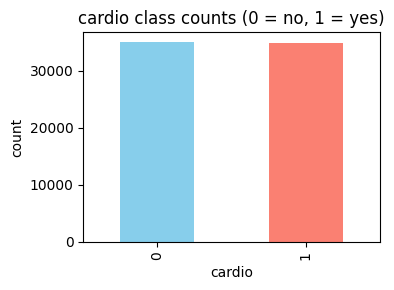

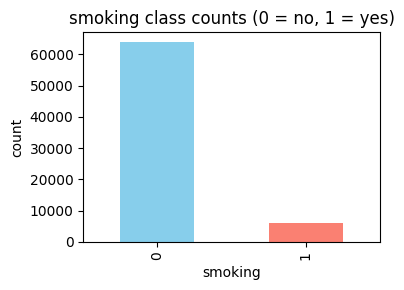

In [105]:
print("summary stats with age_years:")
print(data[["age_years", "height", "weight", "ap_hi", "ap_lo"]].describe())

#Target class distribution
print("\nclass distribution 'cardio':")
print(data["cardio"].value_counts())
print("\nclass distribution (normalized):")
print(data["cardio"].value_counts(normalize=True))

#Plot bat for the target class
plt.figure(figsize=(4,3))
data["cardio"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title("cardio class counts (0 = no, 1 = yes)")
plt.xlabel("cardio")
plt.ylabel("count")
plt.tight_layout()
plt.show()

print("\n")

#Distribution of smoke
plt.figure(figsize=(4,3))
data["smoke"].value_counts().plot(kind="bar", color=["skyblue", "salmon"])
plt.title("smoking class counts (0 = no, 1 = yes)")
plt.xlabel("smoking")
plt.ylabel("count")
plt.tight_layout()
plt.show()


Correlation analysis of numeric features


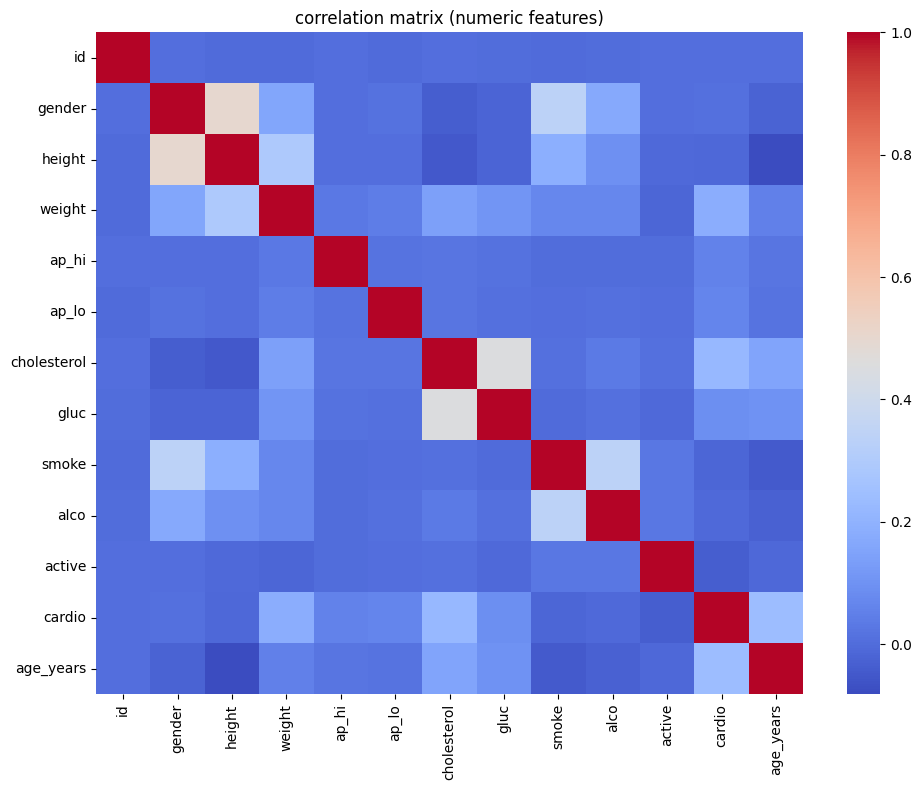

,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
id,1.000000,0.003502,-0.003038,-0.001830,0.003356,-0.002529,0.006106,0.002467,-0.003699,0.001210,0.003755,0.003799,0.003454
gender,0.003502,1.000000,0.499033,0.155406,0.006005,0.015254,-0.035821,-0.020491,0.338135,0.170966,0.005866,0.008109,-0.022794
height,-0.003038,0.499033,1.000000,0.290968,0.005488,0.006150,-0.050226,-0.018595,0.187989,0.094419,-0.006570,-0.010821,-0.081522
weight,-0.001830,0.155406,0.290968,1.000000,0.030702,0.043710,0.141768,0.106857,0.067780,0.067113,-0.016867,0.181660,0.053654
ap_hi,0.003356,0.006005,0.005488,0.030702,1.000000,0.016086,0.023778,0.011841,-0.000922,0.001408,-0.000033,0.054475,0.020778
ap_lo,-0.002529,0.015254,0.006150,0.043710,0.016086,1.000000,0.024019,0.010806,0.005186,0.010601,0.004780,0.065719,0.017630
cholesterol,0.006106,-0.035821,-0.050226,0.141768,0.023778,0.024019,1.000000,0.451578,0.010354,0.035760,0.009911,0.221147,0.154394
gluc,0.002467,-0.020491,-0.018595,0.106857,0.011841,0.010806,0.451578,1.000000,-0.004756,0.011246,-0.006770,0.089307,0.098672
smoke,-0.003699,0.338135,0.187989,0.067780,-0.000922,0.005186,0.010354,-0.004756,1.000000,0.340094,0.025858,-0.015486,-0.047638
alco,0.001210,0.170966,0.094419,0.067113,0.001408,0.010601,0.035760,0.011246,0.340094,1.000000,0.025476,-0.007330,-0.029730


In [106]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = data[numeric_cols].corr() #Pearson correlation

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

corr_matrix #Display matrix


Outlier detection


In [107]:
num_cols_for_outliers = ["age_years", "height", "weight", "ap_hi", "ap_lo"]

outlier_summary = []

#Calculating IQR
for col in num_cols_for_outliers:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    #Countung outliers
    outliers = ((data[col] < lower) | (data[col] > upper)).sum()
    outlier_summary.append((col, outliers, lower, upper))

outlier_df = pd.DataFrame(outlier_summary, columns=["feature", "num_outliers", "lower_bound", "upper_bound"])
print(outlier_df)

     feature  num_outliers  lower_bound  upper_bound
0  age_years             4         33.4         73.4
1     height           519        142.5        186.5
2     weight          1819         39.5        107.5
3      ap_hi          1435         90.0        170.0
4      ap_lo          4632         65.0        105.0


Categorical encoding

In [109]:
# Define categorical columns to one-hot encode
categorical_cols = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]

# Drop the 'id' column since it has no affect or use in our project and it is not a feature
data_no_id = data.drop(columns=["id"])

#Perfom one-hot encoding
data_encoded = pd.get_dummies(
    data_no_id,
    columns=categorical_cols,
    drop_first=True
)

print("shape after one-hot encoding:", data_encoded.shape)
print("new columns:")
print(data_encoded.columns.tolist())


#Seperate the targer class ( maybe not needed )
target = data_encoded["cardio"].copy()

le = LabelEncoder()
y = le.fit_transform(target)

print("unique labels after label encoding:", np.unique(y))



shape after one-hot encoding: (70000, 14)
new columns:
['height', 'weight', 'ap_hi', 'ap_lo', 'cardio', 'age_years', 'gender_2', 'cholesterol_2', 'cholesterol_3', 'gluc_2', 'gluc_3', 'smoke_1', 'alco_1', 'active_1']
unique labels after label encoding: [0 1]


Feature Scaling

In [110]:
# preprocessing/normalization
scaled = data_encoded.copy() #copy data to apply scaling

# standard scaler for continuous features
num_std_cols = ["age_years", "height", "weight", "ap_hi", "ap_lo"]

scaler_std = StandardScaler()
scaled[num_std_cols] = scaler_std.fit_transform(scaled[num_std_cols])

# the other features (all the dummy vars etc.) we can scale with minmax if we want
other_features = [c for c in scaled.columns if c not in num_std_cols + ["cardio"]]

scaler_mm = MinMaxScaler()
scaled[other_features] = scaler_mm.fit_transform(scaled[other_features])

print("scaling done. sample rows:")
scaled.head()


scaling done. sample rows:


,height,weight,ap_hi,ap_lo,cardio,age_years,gender_2,cholesterol_2,cholesterol_3,gluc_2,gluc_3,smoke_1,alco_1,active_1
0,0.443452,-0.847873,-0.122182,-0.088238,0,-0.434868,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1.018168,0.749831,0.072610,-0.035180,1,0.304833,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.078047,-0.708942,0.007679,-0.141297,1,-0.242546,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.565254,0.541435,0.137541,0.017879,1,-0.745543,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-1.018168,-1.264666,-0.187113,-0.194356,0,-0.804719,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Train-Test Split

In [111]:
# features vs target
X = scaled.drop(columns=["cardio"])
y = scaled["cardio"]

print("final feature matrix shape:", X.shape)
print("final target shape:", y.shape)

# Split data into training and testing sets (80 train, 20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nclass distribution in full data:")
print(y.value_counts(normalize=True))

print("\nclass distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nclass distribution in test set:")
print(y_test.value_counts(normalize=True))


final feature matrix shape: (70000, 13)
final target shape: (70000,)


X_train: (56000, 13)
X_test: (14000, 13)
y_train: (56000,)
y_test: (14000,)

class distribution in full data:
cardio
0    0.5003
1    0.4997
Name: proportion, dtype: float64

class distribution in training set:
cardio
0    0.500304
1    0.499696
Name: proportion, dtype: float64

class distribution in test set:
cardio
0    0.500286
1    0.499714
Name: proportion, dtype: float64


Baseline Models Evaluation


Baseline Model Performance:


,Model,Accuracy,Precision,Recall,Train F1,Test F1
0,KNN,0.650143,0.654629,0.634791,0.761574,0.644557
1,Decision Tree,0.633000,0.632714,0.633076,0.999786,0.632895
2,Gaussian NB,0.596643,0.691674,0.347913,0.466883,0.462958



Best baseline model based on Test F1: KNN
              precision    recall  f1-score   support

           0       0.65      0.67      0.66      7004
           1       0.65      0.63      0.64      6996

    accuracy                           0.65     14000
   macro avg       0.65      0.65      0.65     14000
weighted avg       0.65      0.65      0.65     14000



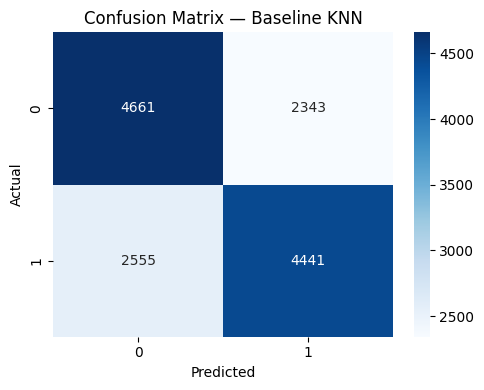

In [69]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


#The models with their default parameters
baseline_models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gaussian NB": GaussianNB()
}

baseline_results = [] #performance metric
baseline_reports = {} #to collect detailed classification reports for each

for name, model in baseline_models.items():

    # train the model on training split
    model.fit(X_train, y_train)

    # predictions on train and test
    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    # basic metrics
    acc  = accuracy_score(y_test, test_pred)
    prec = precision_score(y_test, test_pred, zero_division=0) 
    rec  = recall_score(y_test, test_pred, zero_division=0)
    f1_train = f1_score(y_train, train_pred, zero_division=0) 
    f1_test  = f1_score(y_test, test_pred, zero_division=0)
    # zero_division = 0 avoids issues if a class wasn't predicted (like precision for class 1 if none predicted as 1)

    #store in a list
    baseline_results.append([name, acc, prec, rec, f1_train, f1_test])

    #seperate report for later printing
    baseline_reports[name] = classification_report(y_test, test_pred, zero_division=0)


# summary table, convert to dataframe so we it can be read easly
baseline_df = pd.DataFrame(
    baseline_results,
    columns=["Model", "Accuracy", "Precision", "Recall", "Train F1", "Test F1"]
).sort_values(by="Test F1", ascending=False)

print("\nBaseline Model Performance:")
display(baseline_df)

# pick best baseline model with the highest F1-score
best_baseline_name = baseline_df.iloc[0]["Model"]
best_baseline = baseline_models[best_baseline_name]

print(f"\nBest baseline model based on Test F1: {best_baseline_name}")
print(baseline_reports[best_baseline_name])

# confusion matrix for the best baseline model
best_pred = best_baseline.predict(X_test)
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title(f"Confusion Matrix — Baseline {best_baseline_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


Sample for Hyperparameter Tunning 

In [70]:
#Dataset has 70,000, too long to process so we took 10000 to speed up the cv
sample_size = 10000  

df_sample = scaled.sample(sample_size, random_state=42)

X_sample = df_sample.drop("cardio", axis=1)
y_sample = df_sample["cardio"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sample, y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

print("Sample created:", X_train_s.shape, X_test_s.shape)


Sample created: (8000, 14) (2000, 14)


KNN Modeling & Hyperparemeter Tunning

Running KNN tuning on sample data...
Best odd k: 33


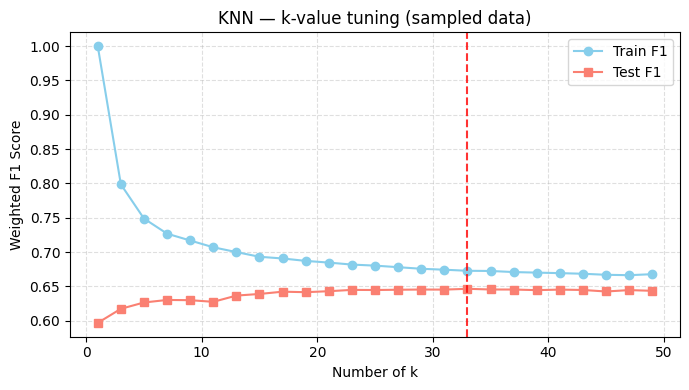

In [71]:
from sklearn.model_selection import cross_validate

print("Running KNN tuning on sample data...")

# 1. Tune k for KNN
k_values = range(1, 51, 2)   # odd values only: 1,3,5,...,49, since even values are useless since they give a 50-50 split
train_scores = []
test_scores = []

for k in k_values:
    # create the model with the current k value, from 1 to 49
    knn = KNeighborsClassifier(n_neighbors=k)  # using default weights and distance for now

    # run 5-fold cross validation using weighted F1
    cv_result = cross_validate(
        knn,
        X_train_s, y_train_s,
        cv=5,
        scoring='f1_weighted',
        return_train_score=True
    )

    # keep the average F1 across the folds
    train_scores.append(cv_result['train_score'].mean())
    test_scores.append(cv_result['test_score'].mean())

# find the k value that gave the best test F1 score
best_k = k_values[np.argmax(test_scores)]
print(f"Best odd k: {best_k}")

# plot how F1 changes with different k values
plt.figure(figsize=(7,4))
plt.plot(k_values, train_scores, marker='o', label='Train F1', color="skyblue")
plt.plot(k_values, test_scores, marker='s', label='Test F1',  color="salmon")
plt.axvline(best_k, color='red', linestyle='--', alpha=0.8) #mark best k
plt.title("KNN — k-value tuning (sampled data)")
plt.xlabel("Number of k")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



Running weight tuning on sample data...
Best weight setting: distance


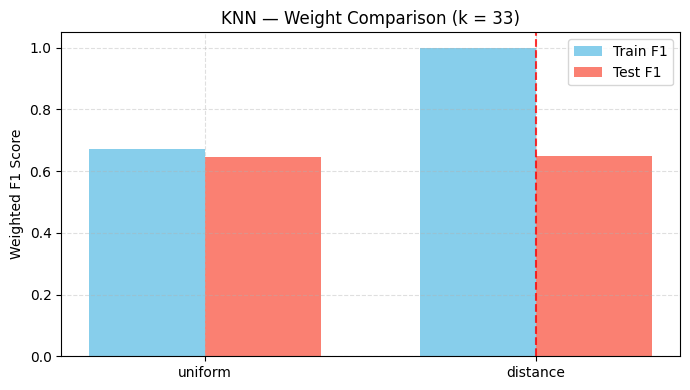

In [72]:
# 2. Tune weight function (uniform vs distance) using the best k found
print("\nRunning weight tuning on sample data...")

weight_options = ["uniform", "distance"]
train_scores_w = []
test_scores_w = []

for w in weight_options:
    knn = KNeighborsClassifier(n_neighbors=best_k, weights=w)

    cv_result = cross_validate(
        knn,
        X_train_s, y_train_s,
        cv=5,
        scoring='f1_weighted',
        return_train_score=True
    )

    train_scores_w.append(cv_result['train_score'].mean())
    test_scores_w.append(cv_result['test_score'].mean())

# find which weight performed better
best_weight = weight_options[np.argmax(test_scores_w)]
print(f"Best weight setting: {best_weight}")

# bar plot to compare the two different weights ( maybe match with other graph)
plt.figure(figsize=(7,4))
x = np.arange(len(weight_options))
width = 0.35
plt.bar(x - width/2, train_scores_w, width, label='Train F1', color="skyblue")
plt.bar(x + width/2, test_scores_w,  width, label='Test F1',  color="salmon")
plt.axvline(np.argmax(test_scores_w), color='red', linestyle='--', alpha=0.8) #mark best weight
plt.xticks(x, weight_options)
plt.ylabel("Weighted F1 Score")
plt.title(f"KNN — Weight Comparison (k = {best_k})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



Running metric tuning on sample data...
Best metric: manhattan


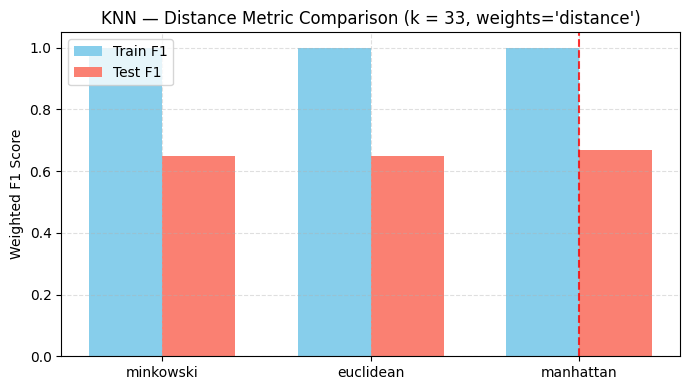

In [74]:
# 3. Tune distance metric (minkowski/euclidean/manhattan) using best k and weight
print("\nRunning metric tuning on sample data...")

metric_options = ["minkowski", "euclidean", "manhattan"]
train_scores_m = []
test_scores_m = []

for m in metric_options:
    knn = KNeighborsClassifier(n_neighbors=best_k, weights=best_weight, metric=m)

    cv_result = cross_validate(
        knn,
        X_train_s, y_train_s,
        cv=5,
        scoring='f1_weighted',
        return_train_score=True
    )

    train_scores_m.append(cv_result['train_score'].mean())
    test_scores_m.append(cv_result['test_score'].mean())

best_metric = metric_options[np.argmax(test_scores_m)]
print(f"Best metric: {best_metric}")

# bar plot to compare the different metrics
plt.figure(figsize=(7,4))
x = np.arange(len(metric_options))
width = 0.35
plt.bar(x - width/2, train_scores_m, width, label='Train F1', color="skyblue")
plt.bar(x + width/2, test_scores_m,  width, label='Test F1',  color="salmon")
plt.axvline(np.argmax(test_scores_m), color='red', linestyle='--', alpha=0.8) #mark best metric
plt.xticks(x, metric_options)
plt.ylabel("Weighted F1 Score")
plt.title(f"KNN — Distance Metric Comparison (k = {best_k}, weights='{best_weight}')")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()




Training final KNN model on FULL dataset...

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.71      0.69      7004
           1       0.69      0.65      0.67      6996

    accuracy                           0.68     14000
   macro avg       0.68      0.68      0.68     14000
weighted avg       0.68      0.68      0.68     14000

Accuracy: 0.6771


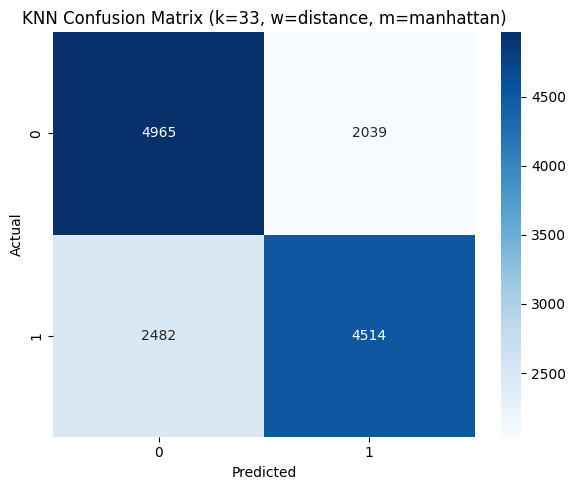

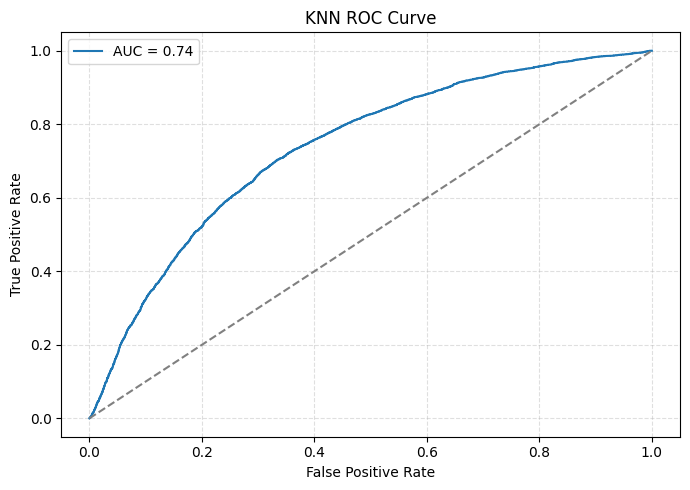


KNN AUC Score: 0.7369


In [86]:
# 4. Train final KNN model on the FULL training set using the optimal hyperparameters extracted from previous steps
print("\nTraining final KNN model on FULL dataset...")

final_knn = KNeighborsClassifier(
    n_neighbors = best_k,
    weights = best_weight,
    metric = best_metric
)


final_knn.fit(X_train, y_train) #train on the full dataset
y_pred = final_knn.predict(X_test)

# basic metrics 
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"KNN Confusion Matrix (k={best_k}, w={best_weight}, m={best_metric})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ROC & AUC
from sklearn.metrics import roc_curve, auc

y_prob = final_knn.predict_proba(X_test)[:, 1]# Probability of class 1 (cardio = yes)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.title("KNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nKNN AUC Score: {auc_score:.4f}")




Decision Tree Hyperparameter Tunning


Tuning Decision Tree max_depth on sample data...
Best max_depth: 4


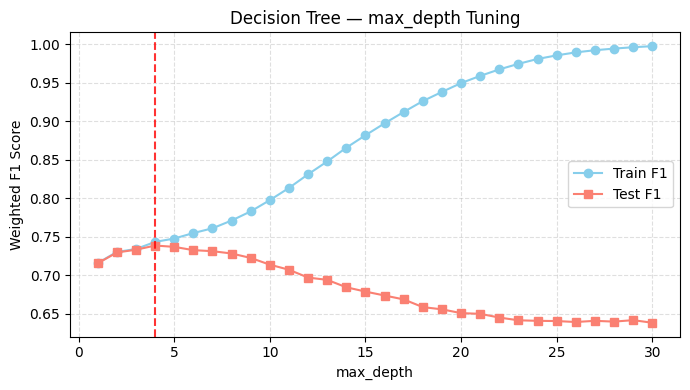

In [78]:
#sampled data
from sklearn.model_selection import cross_validate
print("\nTuning Decision Tree max_depth on sample data...")

# 1. Tune max_depth
depth_values = range(1, 31) #try depths from 1 to 30
train_scores_d = []
test_scores_d = [] 

for d in depth_values:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)

    cv_result = cross_validate(
        dt,
        X_train_s, y_train_s,
        cv=5,
        scoring='f1_weighted',
        return_train_score=True
    )

    train_scores_d.append(cv_result['train_score'].mean())
    test_scores_d.append(cv_result['test_score'].mean())

best_depth = depth_values[np.argmax(test_scores_d)]
print(f"Best max_depth: {best_depth}")

# Plot max-depth
plt.figure(figsize=(7,4))
plt.plot(depth_values, train_scores_d, marker='o', label='Train F1', color="skyblue")
plt.plot(depth_values, test_scores_d, marker='s', label='Test F1', color="salmon")
plt.axvline(best_depth, color='red', linestyle='--', alpha=0.8) #mark best depth
plt.title("Decision Tree — max_depth Tuning")
plt.xlabel("max_depth")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()




Tuning Decision Tree: min_samples_split...
Best min_samples_split: 26


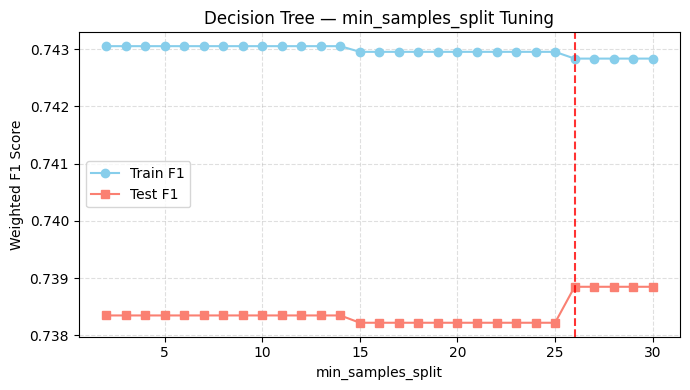

In [ ]:
# 2. Tune min_samples_split
print("\nTuning Decision Tree: min_samples_split...")

split_values = range(2, 31) #try splits from 2 up to 30
train_scores_split = []
test_scores_split = []

for split in split_values:
    dt = DecisionTreeClassifier(
        max_depth = best_depth,
        min_samples_split = split,
        random_state = 42
    )
    
    cv_res = cross_validate(
        dt, X_train_s, y_train_s,
        cv = 5,
        scoring = "f1_weighted",
        return_train_score = True
    )
    
    train_scores_split.append(cv_res["train_score"].mean())
    test_scores_split.append(cv_res["test_score"].mean())

best_split = split_values[np.argmax(test_scores_split)]
print(f"Best min_samples_split: {best_split}")

#Plot min_samples_split
plt.figure(figsize=(7,4))
plt.plot(split_values, train_scores_split, marker='o', label="Train F1", color="skyblue")
plt.plot(split_values, test_scores_split, marker='s', label="Test F1", color="salmon")
plt.axvline(best_split, linestyle='--', color='red', alpha=0.8) #mark best min_split
plt.title("Decision Tree — min_samples_split Tuning")
plt.xlabel("min_samples_split")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Tuning Decision Tree: min_impurity_decrease...
Best min_impurity_decrease: 0.0010526315789473684


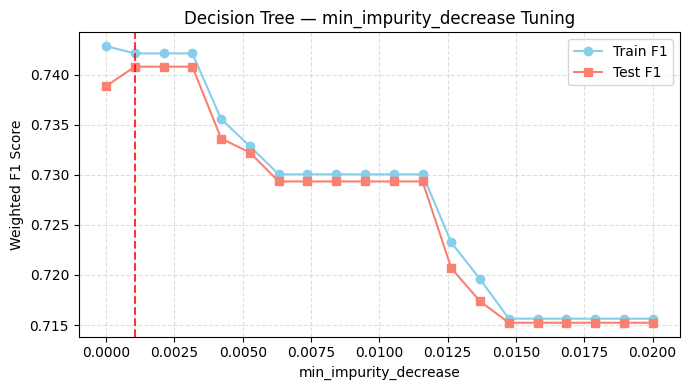

In [81]:
# 3. Tune min_impurity_decrease
print("Tuning Decision Tree: min_impurity_decrease...")

impurity_values = np.linspace(0.0, 0.02, 20)   # s# from 0.00 to 0.02 in 0.001 increments, which prevents overrfiting
train_scores_imp = []
test_scores_imp = []

for val in impurity_values:
    dt = DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_split=best_split,
        min_impurity_decrease=val,
        random_state=42
    )

    cv_result = cross_validate(
        dt,
        X_train_s, y_train_s,
        cv=5,
        scoring='f1_weighted',
        return_train_score=True
    )

    train_scores_imp.append(cv_result['train_score'].mean())
    test_scores_imp.append(cv_result['test_score'].mean())

best_impurity = impurity_values[np.argmax(test_scores_imp)]
print(f"Best min_impurity_decrease: {best_impurity}")

#Plot min_impurity_decrease
plt.figure(figsize=(7,4))
plt.plot(impurity_values, train_scores_imp, marker='o', label='Train F1', color="skyblue")
plt.plot(impurity_values, test_scores_imp, marker='s', label='Test F1', color="salmon")
plt.axvline(best_impurity, color='red', linestyle='--', alpha=0.8) #mark best_impurity
plt.title("Decision Tree — min_impurity_decrease Tuning")
plt.xlabel("min_impurity_decrease")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Tuning Decision Tree: ccp_alpha...
Best ccp_alpha: 0.0


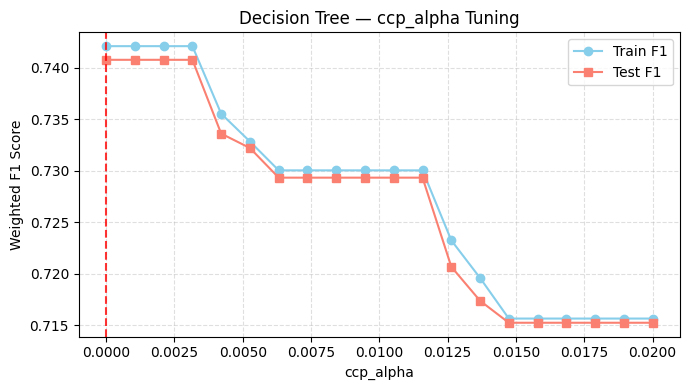

In [82]:
# 4. Tune ccp_alpha (post-pruning)
print("Tuning Decision Tree: ccp_alpha...")

alpha_values = np.linspace(0.0, 0.02, 20) #0 to 0.02
train_scores_alpha = []
test_scores_alpha = []

for a in alpha_values:
    dt = DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_split=best_split,
        min_impurity_decrease=best_impurity,
        ccp_alpha=a,
        random_state=42
    )

    cv_result = cross_validate(
        dt,
        X_train_s, y_train_s,
        cv=5,
        scoring='f1_weighted',
        return_train_score=True
    )

    train_scores_alpha.append(cv_result['train_score'].mean())
    test_scores_alpha.append(cv_result['test_score'].mean())

best_alpha = alpha_values[np.argmax(test_scores_alpha)]
print(f"Best ccp_alpha: {best_alpha}")

#Plot ccp_alpha
plt.figure(figsize=(7,4))
plt.plot(alpha_values, train_scores_alpha, marker='o', label='Train F1', color="skyblue")
plt.plot(alpha_values, test_scores_alpha, marker='s', label='Test F1', color="salmon")
plt.axvline(best_alpha, color='red', linestyle='--', alpha=0.8) #mark alpha values
plt.title("Decision Tree — ccp_alpha Tuning")
plt.xlabel("ccp_alpha")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Tuning Decision Tree: min_samples_leaf...
Best min_samples_leaf: 1


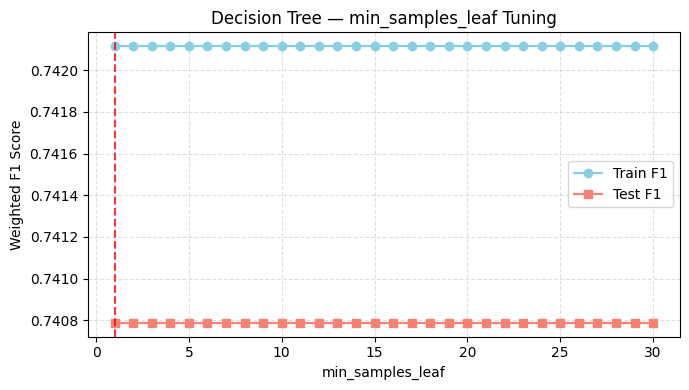

In [83]:
# 5. Tune min_samples_leaf 
print("Tuning Decision Tree: min_samples_leaf...")

leaf_values = range(1, 31) #try leaf sizes 1 through 30
train_scores_leaf = []
test_scores_leaf = []

for leaf in leaf_values:
    dt = DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_split=best_split,
        min_impurity_decrease=best_impurity,
        ccp_alpha=best_alpha,
        min_samples_leaf=leaf,
        random_state=42
    )

    cv_result = cross_validate(
        dt,
        X_train_s, y_train_s,
        cv=5,
        scoring='f1_weighted',
        return_train_score=True
    )

    train_scores_leaf.append(cv_result['train_score'].mean())
    test_scores_leaf.append(cv_result['test_score'].mean())

best_leaf = leaf_values[np.argmax(test_scores_leaf)]
print(f"Best min_samples_leaf: {best_leaf}")

#Plot min_samples_leaf
plt.figure(figsize=(7,4))
plt.plot(leaf_values, train_scores_leaf, marker='o', label='Train F1', color="skyblue")
plt.plot(leaf_values, test_scores_leaf, marker='s', label='Test F1', color="salmon")
plt.axvline(best_leaf, color='red', linestyle='--', alpha=0.8) #mark best_leaf
plt.title("Decision Tree — min_samples_leaf Tuning")
plt.xlabel("min_samples_leaf")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Tuning Decision Tree: max_leaf_nodes...
Best max_leaf_nodes: 10


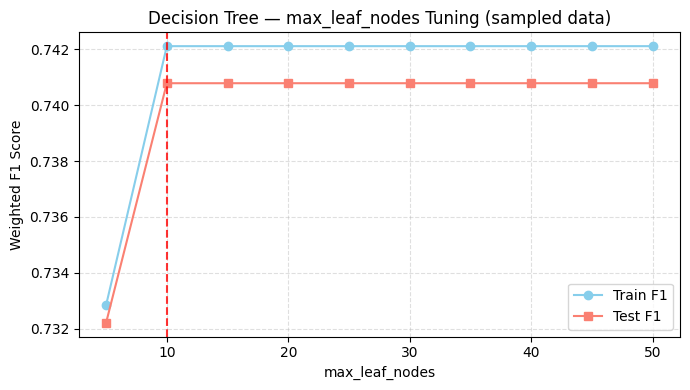

In [84]:
# 6. Tune max_leaf_nodes
print("Tuning Decision Tree: max_leaf_nodes...")

node_values = range(5, 51, 5)  # test from 5 to 50, skip by 5
train_scores_nodes = []
test_scores_nodes = []

for n in node_values:
    dt = DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_split=best_split,
        min_impurity_decrease=best_impurity,
        ccp_alpha=best_alpha,
        min_samples_leaf=best_leaf,
        max_leaf_nodes=n,
        random_state=42
    )

    cv_result = cross_validate(
        dt,
        X_train_s, y_train_s,
        cv=5,
        scoring='f1_weighted',
        return_train_score=True
    )

    train_scores_nodes.append(cv_result['train_score'].mean())
    test_scores_nodes.append(cv_result['test_score'].mean())

best_nodes = node_values[np.argmax(test_scores_nodes)]
print(f"Best max_leaf_nodes: {best_nodes}")

#Plot max_leaf_nodes
plt.figure(figsize=(7,4))
plt.plot(node_values, train_scores_nodes, marker='o', label='Train F1', color="skyblue")
plt.plot(node_values, test_scores_nodes, marker='s', label='Test F1', color="salmon")
plt.axvline(best_nodes, color='red', linestyle='--', alpha=0.8) #mark best_nodes
plt.title("Decision Tree — max_leaf_nodes Tuning (sampled data)")
plt.xlabel("max_leaf_nodes")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



Training final Decision Tree model on FULL dataset...

Decision Tree — Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.72      0.72      7004
           1       0.72      0.73      0.72      6996

    accuracy                           0.72     14000
   macro avg       0.72      0.72      0.72     14000
weighted avg       0.72      0.72      0.72     14000

Accuracy: 0.7234


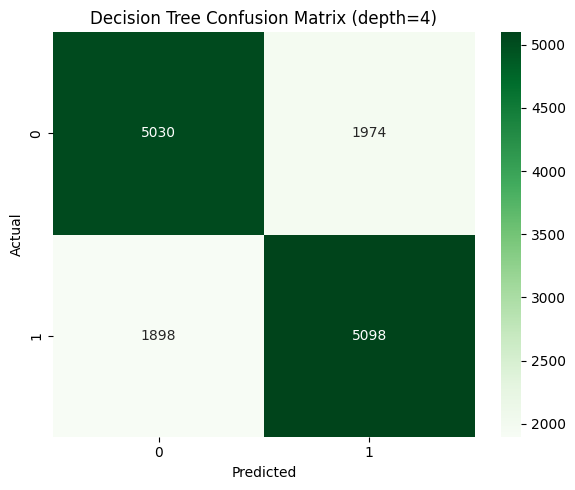

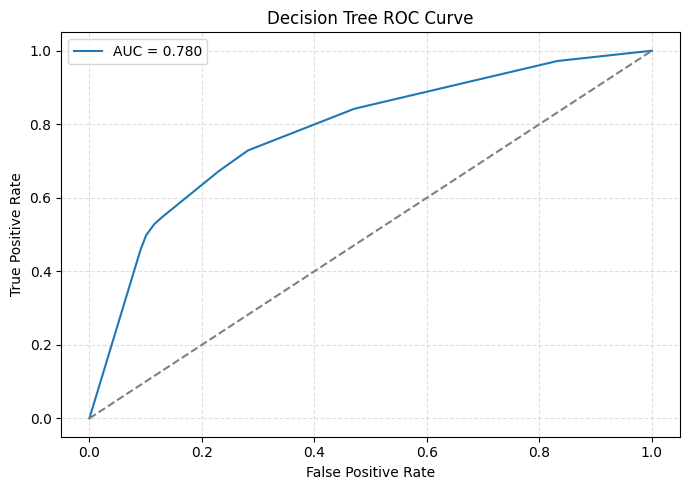


Decision Tree AUC Score: 0.7799


In [85]:
# 7. Train final Decision Tree model on FULL data
print("\nTraining final Decision Tree model on FULL dataset...")

final_dt = DecisionTreeClassifier(
    max_depth = best_depth,
    min_samples_split = best_split,
    min_impurity_decrease = best_impurity,
    min_samples_leaf = best_leaf,
    max_leaf_nodes = best_nodes,
    random_state = 42
)

# train on full training set
final_dt.fit(X_train, y_train)

y_pred_dt = final_dt.predict(X_test)

# basic metric
print("\nDecision Tree — Classification Report:")
print(classification_report(y_test, y_pred_dt))

acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {acc_dt:.4f}")


# confuision matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens")
plt.title(f"Decision Tree Confusion Matrix (depth={best_depth})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ROC & AUC 
y_prob_dt = final_dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(7,5))
plt.plot(fpr_dt, tpr_dt, label=f"AUC = {auc_dt:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.title("Decision Tree ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\nDecision Tree AUC Score: {auc_dt:.4f}")

Naive Bayes Hyperparameter Tunning


Running Naive Bayes comparison on sample data...

Naive Bayes Results:
GaussianNB      Train F1=0.6202 | Test F1=0.6145
BernoulliNB     Train F1=0.5716 | Test F1=0.5710
MultinomialNB   Train F1=0.5779 | Test F1=0.5772

Best NB distribution: GaussianNB


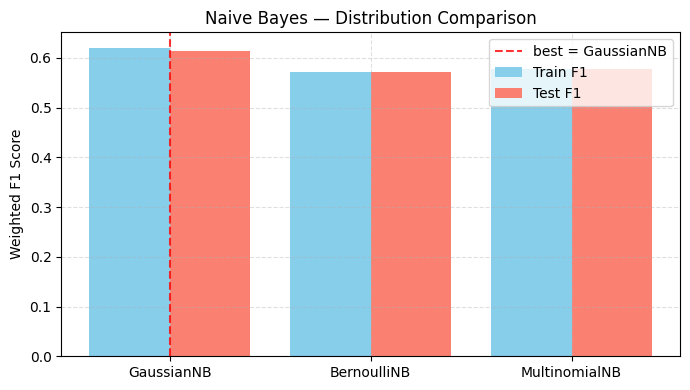

In [87]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

print("\nRunning Naive Bayes comparison on sample data...")

# Ensure features are non-negative for MultinomialNB/BernoulliNB, hence we will use MinMaxScaler
mm_scaler = MinMaxScaler()
X_train_s_mm = mm_scaler.fit_transform(X_train_s)
X_test_s_mm  = mm_scaler.transform(X_test_s)

#Define NB models to compare
nb_models = {
    "GaussianNB": GaussianNB(),
    "BernoulliNB": BernoulliNB(),
    "MultinomialNB": MultinomialNB()
}

train_scores_nb = []
test_scores_nb = []

for name, model in nb_models.items():

    # Bernoulli & Multinomial only work on min-max
    if name in ["BernoulliNB", "MultinomialNB"]:
        X_use = X_train_s_mm
    else:
        X_use = X_train_s

    cv_out = cross_validate(
        model,
        X_use, y_train_s,
        cv=5,
        scoring="f1_weighted",
        return_train_score=True
    )

    train_scores_nb.append(cv_out["train_score"].mean())
    test_scores_nb.append(cv_out["test_score"].mean())

best_nb_idx = np.argmax(test_scores_nb)
best_nb_name = list(nb_models.keys())[best_nb_idx]

print("\nNaive Bayes Results:")
for name, tr, te in zip(nb_models.keys(), train_scores_nb, test_scores_nb):
    print(f"{name:<15} Train F1={tr:.4f} | Test F1={te:.4f}")

print(f"\nBest NB distribution: {best_nb_name}")

#Plot the different NV models
plt.figure(figsize=(7,4))
names = list(nb_models.keys())
x = np.arange(len(names))
plt.bar(x - 0.2, train_scores_nb, width=0.4, label="Train F1", color="skyblue")
plt.bar(x + 0.2, test_scores_nb,  width=0.4, label="Test F1",  color="salmon")
plt.axvline(best_nb_idx, color="red", linestyle="--", alpha=0.8, label=f"best = {best_nb_name}") #mark best_nb_idx
plt.xticks(x, names)
plt.ylabel("Weighted F1 Score")
plt.title("Naive Bayes — Distribution Comparison")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()



Training final Naive Bayes model on FULL dataset...

Naive Bayes — Final Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.85      0.68      7004
           1       0.69      0.35      0.46      6996

    accuracy                           0.60     14000
   macro avg       0.63      0.60      0.57     14000
weighted avg       0.63      0.60      0.57     14000

Accuracy: 0.5966


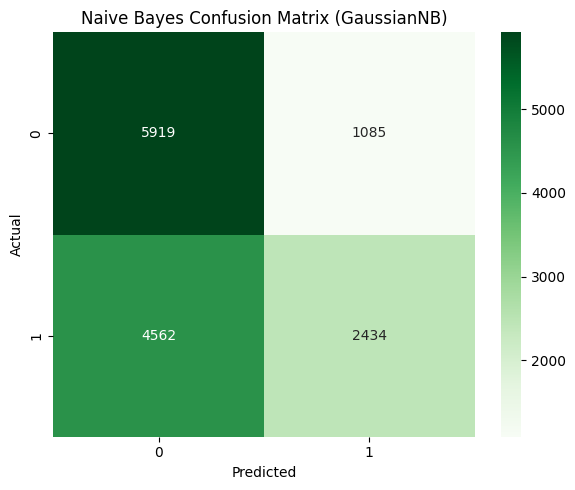

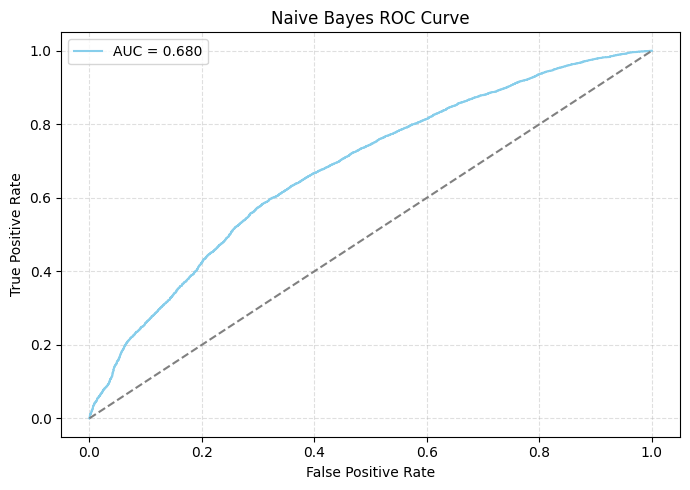


Navie Bayes AUC Score: 0.6801


In [ ]:
# Train final Naive Bayes model on FULL data
print(f"\nTraining final Naive Bayes model on FULL dataset...")

# If it is Bernoulli or Multinomial, we use MinMax on full data
if best_nb_name in ["BernoulliNB", "MultinomialNB"]:
    X_train_full = mm_scaler.fit_transform(X_train)
    X_test_full  = mm_scaler.transform(X_test)
else:
    X_train_full = X_train
    X_test_full  = X_test

final_nb = nb_models[best_nb_name]
final_nb.fit(X_train_full, y_train)

y_pred_nb = final_nb.predict(X_test_full)

# basic metrics
print("\nNaive Bayes — Final Classification Report:")
print(classification_report(y_test, y_pred_nb))

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy: {acc_nb:.4f}")

# confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens")
plt.title(f"Naive Bayes Confusion Matrix ({best_nb_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ROC & AUC

y_prob_nb = final_nb.predict_proba(X_test_full)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)
plt.figure(figsize=(7,5))
plt.plot(fpr_nb, tpr_nb, color="skyblue", label=f"AUC = {auc_nb:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.title("Naive Bayes ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()  

print(f"\nNavie Bayes AUC Score: {auc_nb:.4f}")



KNN Feature Selection (Mutal Information)


Running KNN Feature Selection (Mutual Information)...
Best number of selected features: 2


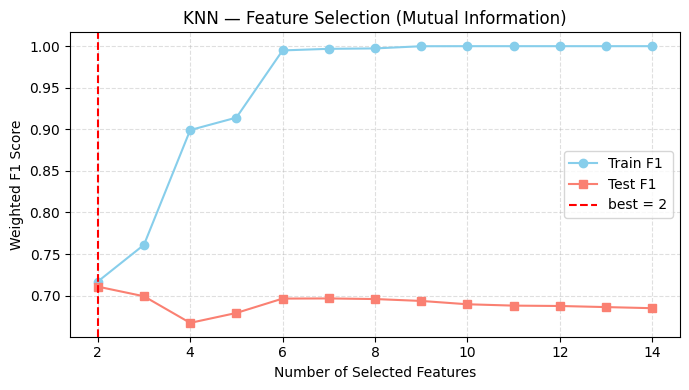

In [91]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import StratifiedKFold

print("\nRunning KNN Feature Selection (Mutual Information)...")

# Cross-validation setup (same everywhere for consistency)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. KNN with Feature Selection

feature_counts = range(2, X_train.shape[1] + 1)
train_scores_fs = []
test_scores_fs = []

# Loop over different numbers of selected features
for k in feature_counts:
    selector = SelectKBest(
        score_func=lambda X, y: mutual_info_classif(X, y, random_state=42),
        k=k
    )

    X_train_k = selector.fit_transform(X_train, y_train)
    X_test_k = selector.transform(X_test)

    knn_fs = KNeighborsClassifier(
        n_neighbors = best_k,
        weights = best_weight,
        metric = best_metric
    )

    cv_result = cross_validate(
        knn_fs,
        X_train_k, y_train,
        cv=cv,
        scoring='f1_weighted',
        return_train_score=True
    )

    train_scores_fs.append(cv_result['train_score'].mean())
    test_scores_fs.append(cv_result['test_score'].mean())

# Pick the best number of selected features
best_k_features = feature_counts[np.argmax(test_scores_fs)]
print(f"Best number of selected features: {best_k_features}")


#Plot the number of selected features
plt.figure(figsize=(7,4))
plt.plot(feature_counts, train_scores_fs, marker='o', label='Train F1', color="skyblue")
plt.plot(feature_counts, test_scores_fs, marker='s', label='Test F1', color="salmon")
plt.axvline(best_k_features, color='red', linestyle='--', label=f"best = {best_k_features}") #mark best_k_features
plt.title("KNN — Feature Selection (Mutual Information)")
plt.xlabel("Number of Selected Features")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



Classification Report (WITH Feature Selection):
              precision    recall  f1-score   support

           0       0.68      0.81      0.74      7004
           1       0.76      0.61      0.68      6996

    accuracy                           0.71     14000
   macro avg       0.72      0.71      0.71     14000
weighted avg       0.72      0.71      0.71     14000

Accuracy with Feature Selection: 0.7099


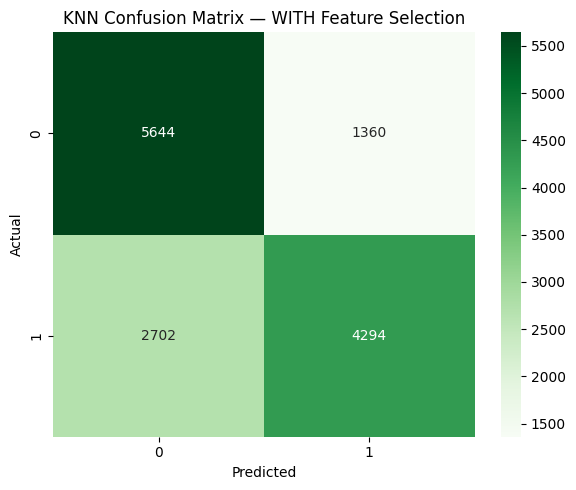

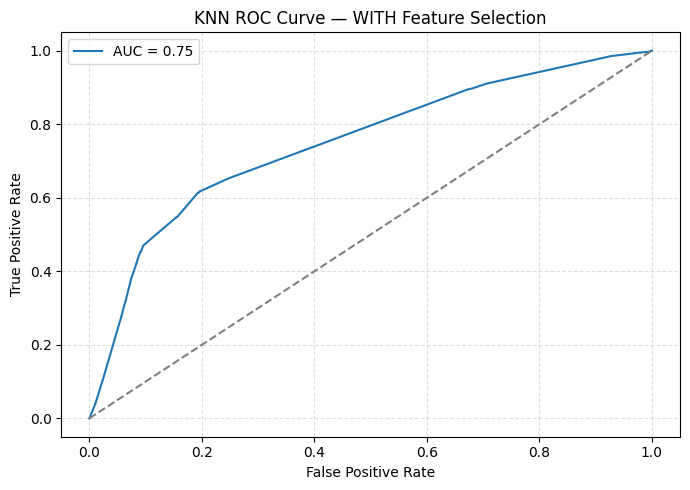

AUC (KNN with FS) = 0.7500


In [92]:
# Train final KNN model WITH selected features
selector = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, random_state=42),
    k=best_k_features
)

X_train_fs = selector.fit_transform(X_train, y_train)
X_test_fs = selector.transform(X_test)

final_knn_fs = KNeighborsClassifier(
    n_neighbors = best_k,
    weights = best_weight,
    metric = best_metric
)

final_knn_fs.fit(X_train_fs, y_train)
y_pred_fs = final_knn_fs.predict(X_test_fs)

print("\nClassification Report (WITH Feature Selection):")
print(classification_report(y_test, y_pred_fs))

acc_fs = accuracy_score(y_test, y_pred_fs)
print(f"Accuracy with Feature Selection: {acc_fs:.4f}")

# confusion matrix 
cm_fs = confusion_matrix(y_test, y_pred_fs)
plt.figure(figsize=(6,5))
sns.heatmap(cm_fs, annot=True, fmt='d', cmap='Greens')
plt.title("KNN Confusion Matrix — WITH Feature Selection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ROC + AUC
y_prob_pos = final_knn_fs.predict_proba(X_test_fs)[:, 1]  
fpr, tpr, _ = roc_curve(y_test, y_prob_pos)
auc_score = auc(fpr, tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.title("KNN ROC Curve — WITH Feature Selection")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"AUC (KNN with FS) = {auc_score:.4f}")

Desicion Tree with Feature Selection


Running Decision Tree Feature Selection (Mutual Information)...
Best number of features for Decision Tree: 5


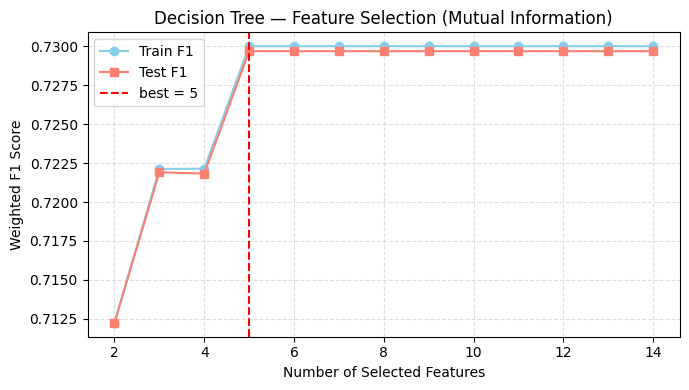

In [93]:
# 2. Decision Tree with Feature Selection

print("\nRunning Decision Tree Feature Selection (Mutual Information)...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Try selecting from 2 features up to all features
feature_counts = range(2, X_train.shape[1] + 1)
train_scores_fs_dt = []
test_scores_fs_dt = []

for k in feature_counts:
    selector = SelectKBest(
        score_func=lambda X, y: mutual_info_classif(X, y, random_state=42),
        k=k
    )

    X_train_k = selector.fit_transform(X_train, y_train)
    X_test_k = selector.transform(X_test)

    dt_fs = DecisionTreeClassifier(
        max_depth = best_depth,
        min_samples_split = best_split,
        min_impurity_decrease = best_impurity,
        min_samples_leaf = best_leaf,
        max_leaf_nodes = best_nodes,
        random_state = 42
    )

    cv_result = cross_validate(
        dt_fs,
        X_train_k, y_train,
        cv=cv,
        scoring='f1_weighted',
        return_train_score=True
    )

    train_scores_fs_dt.append(cv_result['train_score'].mean())
    test_scores_fs_dt.append(cv_result['test_score'].mean())


best_k_features_dt = feature_counts[np.argmax(test_scores_fs_dt)]
print(f"Best number of features for Decision Tree: {best_k_features_dt}")


# Plot the number of features
plt.figure(figsize=(7,4))
plt.plot(feature_counts, train_scores_fs_dt, marker='o', label='Train F1', color="skyblue")
plt.plot(feature_counts, test_scores_fs_dt, marker='s', label='Test F1', color="salmon")
plt.axvline(best_k_features_dt, color='red', linestyle='--', label=f"best = {best_k_features_dt}") #mark best_k_features_dt
plt.title("Decision Tree — Feature Selection (Mutual Information)")
plt.xlabel("Number of Selected Features")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



Classification Report (Decision Tree WITH Feature Selection):
              precision    recall  f1-score   support

           0       0.73      0.72      0.72      7004
           1       0.72      0.73      0.72      6996

    accuracy                           0.72     14000
   macro avg       0.72      0.72      0.72     14000
weighted avg       0.72      0.72      0.72     14000

Accuracy with Feature Selection: 0.7234


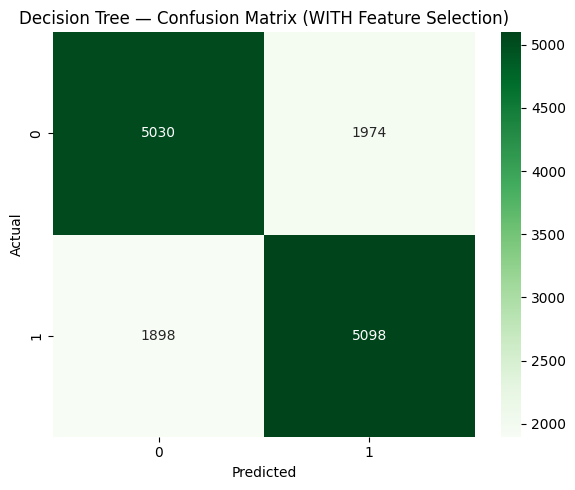

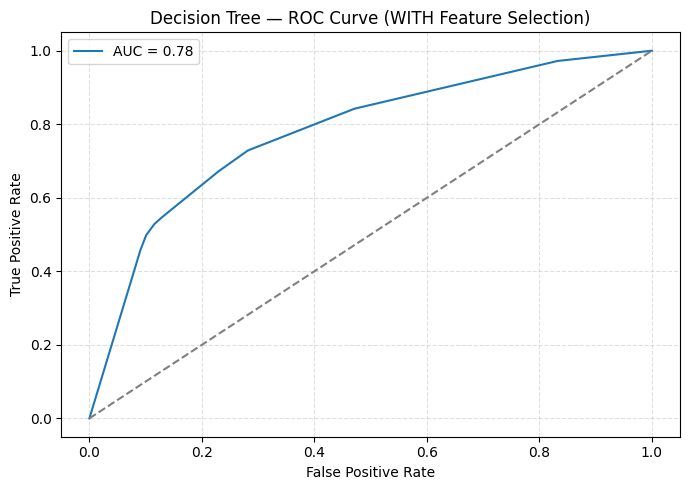

AUC (with Feature Selection): 0.7799


In [94]:
# Train final Decision Tree model WITH selected features
selector_dt = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, random_state=42),
    k=best_k_features_dt
)

X_train_fs_dt = selector_dt.fit_transform(X_train, y_train)
X_test_fs_dt = selector_dt.transform(X_test)

final_dt_fs = DecisionTreeClassifier(
    max_depth = best_depth,
    min_samples_split = best_split,
    min_impurity_decrease = best_impurity,
    min_samples_leaf = best_leaf,
    max_leaf_nodes = best_nodes,
    random_state = 42
)

final_dt_fs.fit(X_train_fs_dt, y_train)
y_pred_fs_dt = final_dt_fs.predict(X_test_fs_dt)

print("\nClassification Report (Decision Tree WITH Feature Selection):")
print(classification_report(y_test, y_pred_fs_dt))

acc_fs_dt = accuracy_score(y_test, y_pred_fs_dt)
print(f"Accuracy with Feature Selection: {acc_fs_dt:.4f}")


# confusion matrix
cm_fs_dt = confusion_matrix(y_test, y_pred_fs_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm_fs_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree — Confusion Matrix (WITH Feature Selection)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ROC + AUC 
y_prob_fs_dt = final_dt_fs.predict_proba(X_test_fs_dt)[:, 1]   # probability of class 1
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_fs_dt)
auc_dt_fs = auc(fpr_dt, tpr_dt)
plt.figure(figsize=(7,5))
plt.plot(fpr_dt, tpr_dt, label=f"AUC = {auc_dt_fs:.2f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.title("Decision Tree — ROC Curve (WITH Feature Selection)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print(f"AUC (with Feature Selection): {auc_dt_fs:.4f}")

Naive Bayes with Feature Selection


Running Naive Bayes Feature Selection (Mutual Information)...
Best number of features for Naive Bayes: 11


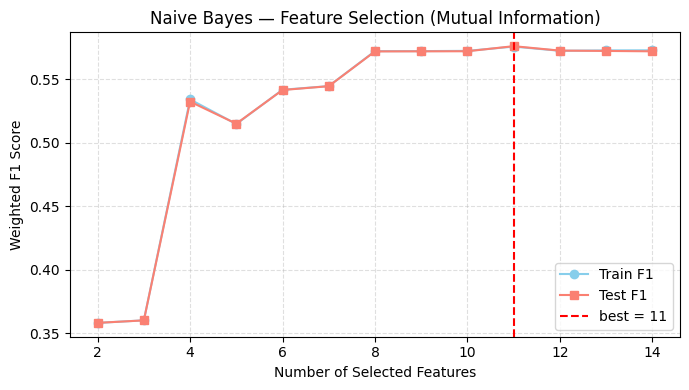

In [95]:
# 3. Naive Bayes with Feature Selection

print("\nRunning Naive Bayes Feature Selection (Mutual Information)...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

feature_counts_nb = range(2, X_train.shape[1] + 1)
train_scores_nb = []
test_scores_nb = []

for k in feature_counts_nb:

    selector_nb = SelectKBest(
        score_func=lambda X, y: mutual_info_classif(X, y, random_state=42),
        k=k
    )

    X_train_fs_nb = selector_nb.fit_transform(X_train, y_train)
    X_test_fs_nb = selector_nb.transform(X_test)

    nb_model = GaussianNB()

    cv_result_nb = cross_validate(
        nb_model,
        X_train_fs_nb, y_train,
        cv=cv,
        scoring='f1_weighted',
        return_train_score=True
    )

    train_scores_nb.append(cv_result_nb['train_score'].mean())
    test_scores_nb.append(cv_result_nb['test_score'].mean())

best_k_nb = feature_counts_nb[np.argmax(test_scores_nb)]
print(f"Best number of features for Naive Bayes: {best_k_nb}")

# Plot the number of features
plt.figure(figsize=(7,4))
plt.plot(feature_counts_nb, train_scores_nb, marker='o', label='Train F1', color="skyblue")
plt.plot(feature_counts_nb, test_scores_nb, marker='s', label='Test F1', color="salmon")
plt.axvline(best_k_nb, color='red', linestyle='--', label=f"best = {best_k_nb}") #mark best_k_nb
plt.title("Naive Bayes — Feature Selection (Mutual Information)")
plt.xlabel("Number of Selected Features")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Classification Report (Naive Bayes WITH Feature Selection):
              precision    recall  f1-score   support

           0       0.57      0.86      0.68      7004
           1       0.71      0.35      0.47      6996

    accuracy                           0.60     14000
   macro avg       0.64      0.60      0.57     14000
weighted avg       0.64      0.60      0.57     14000

Accuracy with Feature Selection: 0.6022


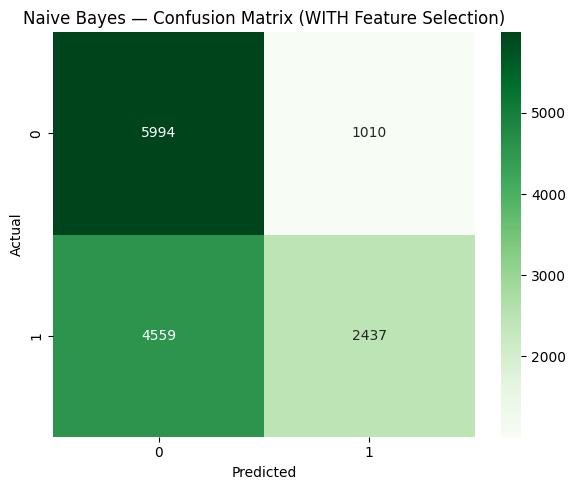

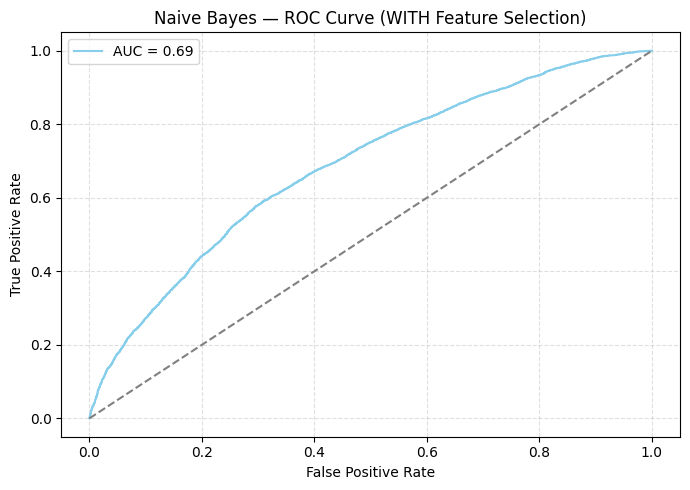

AUC (with Feature Selection): 0.6860


In [96]:
 # Train final NB model WITH selected features

selector_nb_final = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, random_state=42),
    k=best_k_nb
)

X_train_nb_final = selector_nb_final.fit_transform(X_train, y_train)
X_test_nb_final = selector_nb_final.transform(X_test)

final_nb_fs = GaussianNB()
final_nb_fs.fit(X_train_nb_final, y_train)

y_pred_nb_fs = final_nb_fs.predict(X_test_nb_final)

print("\nClassification Report (Naive Bayes WITH Feature Selection):")
print(classification_report(y_test, y_pred_nb_fs))

acc_nb_fs = accuracy_score(y_test, y_pred_nb_fs)
print(f"Accuracy with Feature Selection: {acc_nb_fs:.4f}")


# confusion matrix
cm_nb_fs = confusion_matrix(y_test, y_pred_nb_fs)
plt.figure(figsize=(6,5))
sns.heatmap(cm_nb_fs, annot=True, fmt='d', cmap='Greens')
plt.title("Naive Bayes — Confusion Matrix (WITH Feature Selection)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ROC + AUC
y_prob_nb = final_nb_fs.predict_proba(X_test_nb_final)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb_fs = auc(fpr_nb, tpr_nb)
plt.figure(figsize=(7,5))
plt.plot(fpr_nb, tpr_nb, label=f"AUC = {auc_nb_fs:.2f}", color="skyblue")
plt.plot([0,1], [0,1], '--', color="gray")
plt.title("Naive Bayes — ROC Curve (WITH Feature Selection)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"AUC (with Feature Selection): {auc_nb_fs:.4f}")

PCA


Running PCA dimensionality reduction...
Number of PCA components to keep ≥ 90% variance: 7


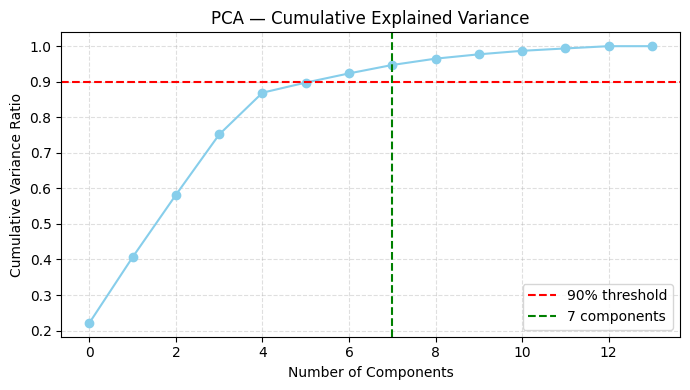

PCA-transformed shapes: (56000, 7), (14000, 7)


In [97]:
from sklearn.decomposition import PCA

print("\nRunning PCA dimensionality reduction...")


# We will apply PCA on the standardized feature but since we already scaled X in the beginning, we dont have to do it again
# Use a copy of X_train and X_test to avoid altering original
X_train_scaled_pca = X_train.copy()
X_test_scaled_pca  = X_test.copy()


# Fit PCA on training set only
pca = PCA()
pca.fit(X_train_scaled_pca)

explained_var = np.cumsum(pca.explained_variance_ratio_)

# Find number of components to reach at least 90% variance
n_components_90 = np.argmax(explained_var >= 0.90) + 1 # +1, because argmax starts with index 0
print(f"Number of PCA components to keep ≥ 90% variance: {n_components_90}")


# Plot explained variance curve
plt.figure(figsize=(7,4))
plt.plot(explained_var, marker='o', color="skyblue")
plt.axhline(0.90, color='red', linestyle='--', label='90% threshold')
plt.axvline(n_components_90, color='green', linestyle='--', label=f'{n_components_90} components')
plt.title("PCA — Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Ratio")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Applying PCA transformation with the chosen number of components
pca_final = PCA(n_components=n_components_90)
X_train_pca = pca_final.fit_transform(X_train_scaled_pca)
X_test_pca  = pca_final.transform(X_test_scaled_pca)

print(f"PCA-transformed shapes: {X_train_pca.shape}, {X_test_pca.shape}")


KNN with Dimensionality Reduction


Running KNN Evaluation with PCA

Classification Report (KNN + PCA):
              precision    recall  f1-score   support

           0       0.65      0.71      0.68      7004
           1       0.68      0.62      0.65      6996

    accuracy                           0.67     14000
   macro avg       0.67      0.67      0.67     14000
weighted avg       0.67      0.67      0.67     14000

Accuracy (KNN + PCA): 0.6666


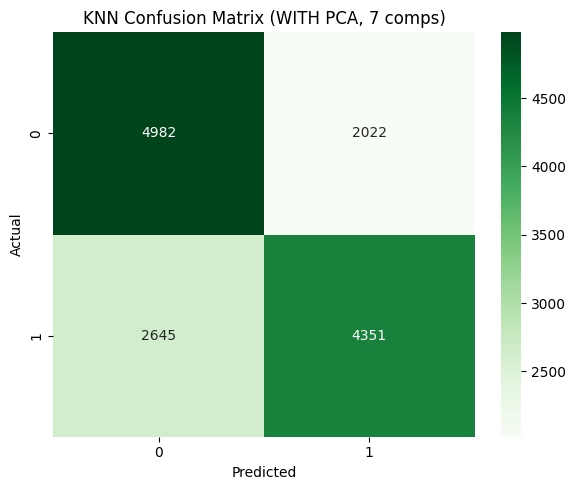

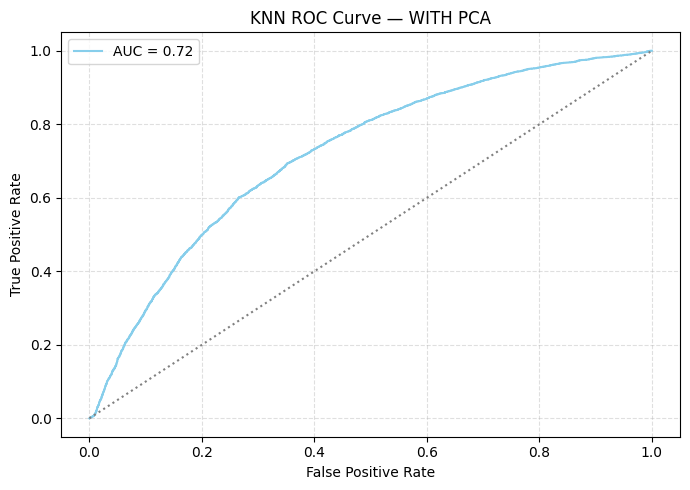

KNN AUC (WITH PCA): 0.7212


In [98]:
# 1. KNN with PCA
print("\nRunning KNN Evaluation with PCA")

knn_pca = KNeighborsClassifier(
    n_neighbors = best_k,
    weights = best_weight,
    metric = best_metric
)

knn_pca.fit(X_train_pca, y_train)
y_pred_knn_pca = knn_pca.predict(X_test_pca)

print("\nClassification Report (KNN + PCA):")
print(classification_report(y_test, y_pred_knn_pca))

acc_knn_pca = accuracy_score(y_test, y_pred_knn_pca)
print(f"Accuracy (KNN + PCA): {acc_knn_pca:.4f}")

# confusion matrix
cm_knn_pca = confusion_matrix(y_test, y_pred_knn_pca)
plt.figure(figsize=(6,5))
sns.heatmap(cm_knn_pca, annot=True, fmt="d", cmap="Greens")
plt.title(f"KNN Confusion Matrix (WITH PCA, {n_components_90} comps)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC + AUC 
y_prob_knn_pca = knn_pca.predict_proba(X_test_pca)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_knn_pca)
auc_knn_pca = auc(fpr, tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_knn_pca:.2f}", color="skyblue")
plt.plot([0,1], [0,1], ":", color="gray")
plt.title("KNN ROC Curve — WITH PCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"KNN AUC (WITH PCA): {auc_knn_pca:.4f}")


Decision Tree with Dimensionality Reduction


Running Decision Tree Evaluation with PCA

Classification Report (DT + PCA):
              precision    recall  f1-score   support

           0       0.60      0.77      0.67      7004
           1       0.68      0.49      0.57      6996

    accuracy                           0.63     14000
   macro avg       0.64      0.63      0.62     14000
weighted avg       0.64      0.63      0.62     14000

Accuracy (DT + PCA): 0.6284


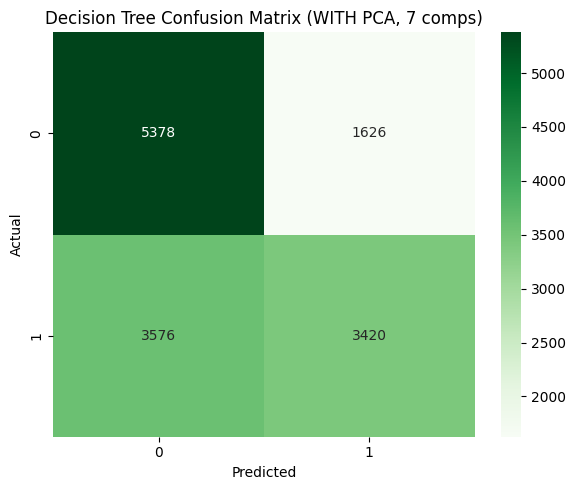

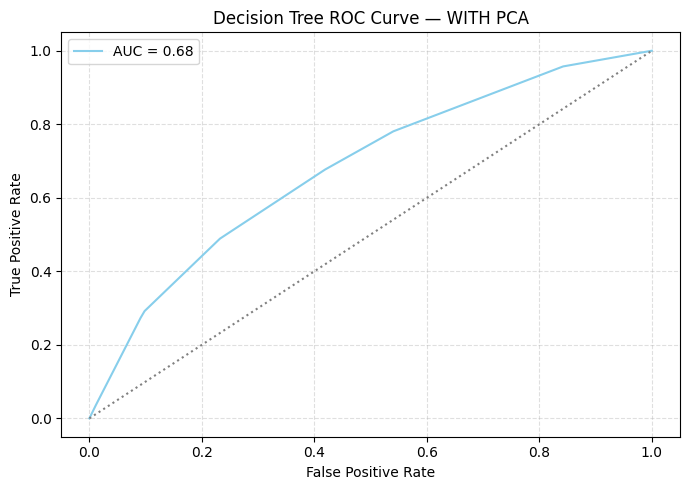

Decision Tree AUC (WITH PCA): 0.6809


In [102]:
# 2. Decision Tree with PCA

print("\nRunning Decision Tree Evaluation with PCA")

dt_pca = DecisionTreeClassifier(
    max_depth = best_depth,
    min_samples_split = best_split,
    min_impurity_decrease = best_impurity,
    min_samples_leaf = best_leaf,
    max_leaf_nodes = best_nodes,
    random_state = 42
)

dt_pca.fit(X_train_pca, y_train)
y_pred_dt_pca = dt_pca.predict(X_test_pca)

print("\nClassification Report (DT + PCA):")
print(classification_report(y_test, y_pred_dt_pca))

acc_dt_pca = accuracy_score(y_test, y_pred_dt_pca)
print(f"Accuracy (DT + PCA): {acc_dt_pca:.4f}")

# confusion matrix
cm_dt_pca = confusion_matrix(y_test, y_pred_dt_pca)
plt.figure(figsize=(6,5))
sns.heatmap(cm_dt_pca, annot=True, fmt="d", cmap="Greens")
plt.title(f"Decision Tree Confusion Matrix (WITH PCA, {n_components_90} comps)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC + AUC
y_prob_dt_pca = dt_pca.predict_proba(X_test_pca)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt_pca)
auc_dt_pca = auc(fpr_dt, tpr_dt)
plt.figure(figsize=(7,5))
plt.plot(fpr_dt, tpr_dt, label=f"AUC = {auc_dt_pca:.2f}", color="skyblue")
plt.plot([0,1], [0,1], ":", color="gray")
plt.title("Decision Tree ROC Curve — WITH PCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Decision Tree AUC (WITH PCA): {auc_dt_pca:.4f}")


Navie Bayes with Dimensionality Reduction


Running Naive Bayes Evaluation with PCA

Classification Report (NB + PCA):
              precision    recall  f1-score   support

           0       0.56      0.86      0.68      7004
           1       0.70      0.32      0.44      6996

    accuracy                           0.59     14000
   macro avg       0.63      0.59      0.56     14000
weighted avg       0.63      0.59      0.56     14000

Accuracy (NB + PCA): 0.5908


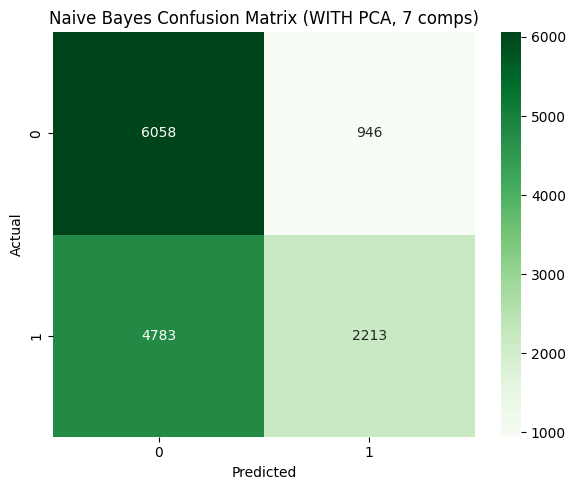

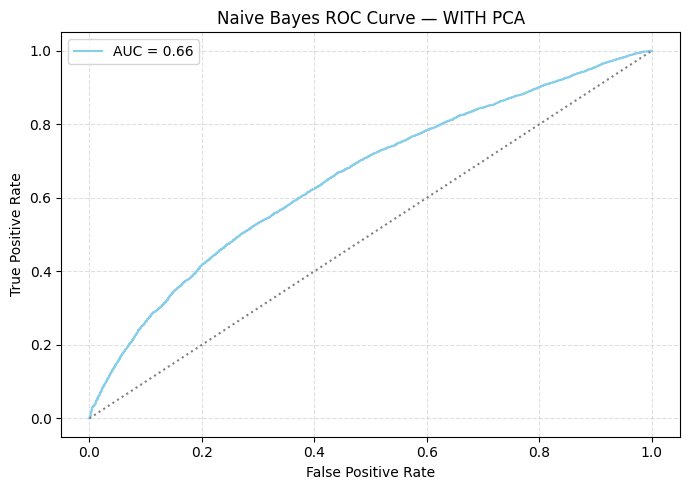

Naive Bayes AUC (WITH PCA): 0.6560


In [103]:
# 3. Naive Bayes with PCA
print("\nRunning Naive Bayes Evaluation with PCA")

nb_pca = GaussianNB()

nb_pca.fit(X_train_pca, y_train)
y_pred_nb_pca = nb_pca.predict(X_test_pca)

print("\nClassification Report (NB + PCA):")
print(classification_report(y_test, y_pred_nb_pca))

acc_nb_pca = accuracy_score(y_test, y_pred_nb_pca)
print(f"Accuracy (NB + PCA): {acc_nb_pca:.4f}")

# confusion matrix
cm_nb_pca = confusion_matrix(y_test, y_pred_nb_pca)
plt.figure(figsize=(6,5))
sns.heatmap(cm_nb_pca, annot=True, fmt="d", cmap="Greens")
plt.title(f"Naive Bayes Confusion Matrix (WITH PCA, {n_components_90} comps)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC + AUC
y_prob_nb_pca = nb_pca.predict_proba(X_test_pca)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb_pca)
auc_nb_pca = auc(fpr_nb, tpr_nb)
plt.figure(figsize=(7,5))
plt.plot(fpr_nb, tpr_nb, label=f"AUC = {auc_nb_pca:.2f}", color="skyblue")
plt.plot([0,1], [0,1], ":", color="gray")
plt.title("Naive Bayes ROC Curve — WITH PCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Naive Bayes AUC (WITH PCA): {auc_nb_pca:.4f}")
